In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
# Load red wine dataset
from google.colab import drive
drive.mount('/content/drive')

red_wine = "/content/drive/MyDrive/Datasets/winequality-red.csv"

df = None # Initialize df to None

try:
    df = pd.read_csv(red_wine, sep=';')
    print(f"Dataset loaded from user-provided path: '{red_wine}' successfully.")
except Exception as e_path:
    print(f"Failed to load dataset from user-provided path: '{red_wine}' ({e_path}).")
    print("Error: Cannot load dataset. Please ensure file exists or path is correct.")

if df is not None:
    print(f"\nDataset shape: {df.shape}")
    print(f"\nFirst few rows:")
    df.head()
else:
    print("\nDataFrame 'df' was not created because the loading attempt failed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded from user-provided path: '/content/drive/MyDrive/Datasets/winequality-red.csv' successfully.

Dataset shape: (1599, 12)

First few rows:


In [7]:
# Basic data exploration
print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nQuality distribution:\n{df['quality'].value_counts().sort_index()}")
print(f"\nBasic statistics:")
df.describe()

Dataset Information:
Shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Basic statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


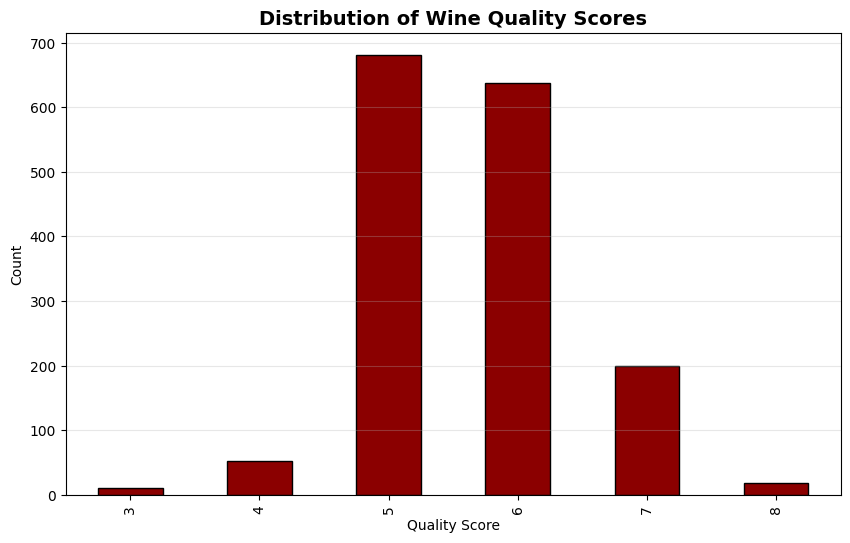

Quality range: 3 to 8
Mean quality: 5.64


In [8]:
# Visualize quality distribution
plt.figure(figsize=(10, 6))
df['quality'].value_counts().sort_index().plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Quality range: {df['quality'].min()} to {df['quality'].max()}")
print(f"Mean quality: {df['quality'].mean():.2f}")

In [9]:
# Prepare features for clustering
X = df.drop(columns=['quality'])
y_true = df['quality']

print(f"Features shape: {X.shape}")
print(f"Feature names: {X.columns.tolist()}")

Features shape: (1599, 11)
Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [10]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled using StandardScaler")
print(f"Scaled data shape: {X_scaled.shape}")

Features scaled using StandardScaler
Scaled data shape: (1599, 11)


## K-Means Clustering

In [11]:
# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
db_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    db_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

print("Elbow method analysis completed")

Elbow method analysis completed


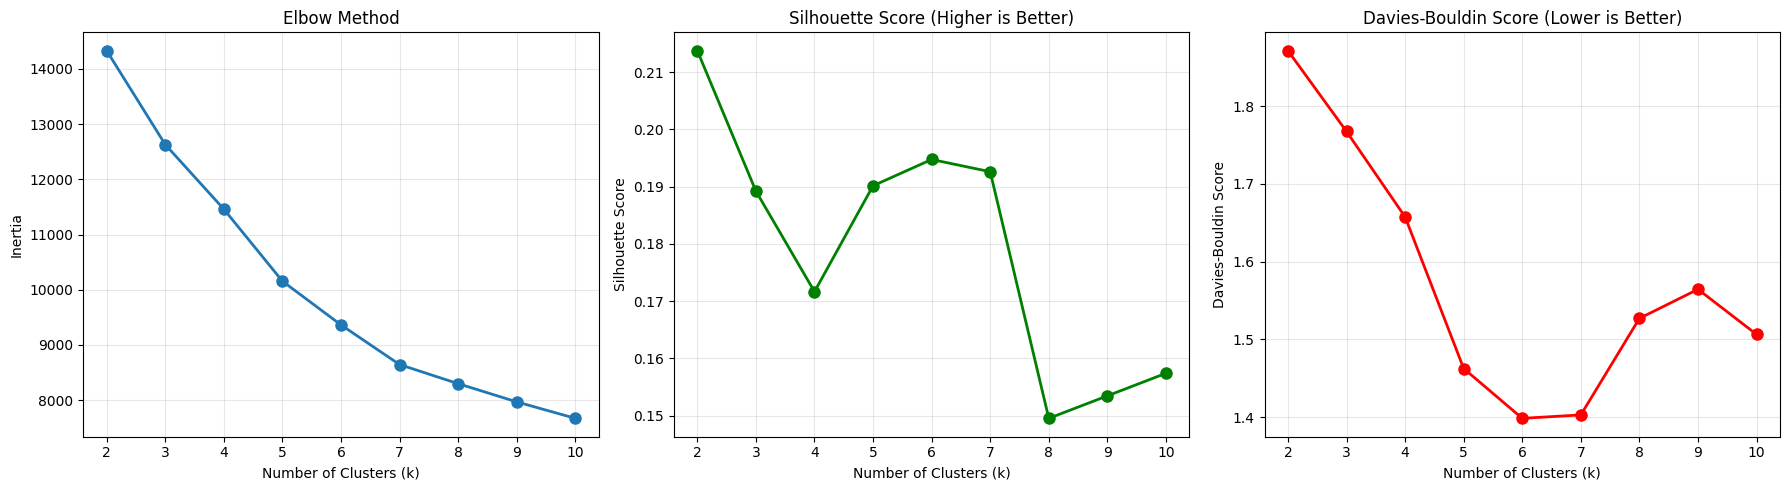


Metrics for different k values:
k=2: Inertia=14330.12, Silhouette=0.214, Davies-Bouldin=1.871
k=3: Inertia=12629.97, Silhouette=0.189, Davies-Bouldin=1.767
k=4: Inertia=11459.14, Silhouette=0.172, Davies-Bouldin=1.657
k=5: Inertia=10155.51, Silhouette=0.190, Davies-Bouldin=1.463
k=6: Inertia=9363.21, Silhouette=0.195, Davies-Bouldin=1.398
k=7: Inertia=8645.20, Silhouette=0.193, Davies-Bouldin=1.403
k=8: Inertia=8298.97, Silhouette=0.150, Davies-Bouldin=1.527
k=9: Inertia=7969.34, Silhouette=0.153, Davies-Bouldin=1.564
k=10: Inertia=7671.02, Silhouette=0.157, Davies-Bouldin=1.506


In [12]:
# Visualize elbow method and metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow curve
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, marker='o', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(alpha=0.3)

# Davies-Bouldin score
axes[2].plot(k_range, db_scores, marker='o', color='red', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMetrics for different k values:")
for i, k in enumerate(k_range):
    print(f"k={k}: Inertia={inertias[i]:.2f}, Silhouette={silhouette_scores[i]:.3f}, Davies-Bouldin={db_scores[i]:.3f}")

In [13]:
# Select optimal k based on quality range (3-8)
optimal_k = 6
print(f"Using k={optimal_k} clusters (matching quality range 3-8)")

# Fit K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate metrics
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"\nK-Means Clustering Results (k={optimal_k}):")
print(f"Silhouette Score: {silhouette_kmeans:.3f}")
print(f"Davies-Bouldin Index: {db_kmeans:.3f}")
print(f"\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Using k=6 clusters (matching quality range 3-8)

K-Means Clustering Results (k=6):
Silhouette Score: 0.195
Davies-Bouldin Index: 1.398

Cluster sizes:
0     34
1     30
2    302
3    533
4    338
5    362
Name: count, dtype: int64


## Hierarchical Clustering

In [14]:
# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Calculate metrics
silhouette_hier = silhouette_score(X_scaled, hierarchical_labels)
db_hier = davies_bouldin_score(X_scaled, hierarchical_labels)

print(f"Hierarchical Clustering Results (k={optimal_k}):")
print(f"Silhouette Score: {silhouette_hier:.3f}")
print(f"Davies-Bouldin Index: {db_hier:.3f}")
print(f"\nCluster sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Hierarchical Clustering Results (k=6):
Silhouette Score: 0.150
Davies-Bouldin Index: 1.526

Cluster sizes:
0    485
1    530
2    327
3     33
4     99
5    125
Name: count, dtype: int64


## DBSCAN Clustering

In [15]:
# DBSCAN clustering
dbscan = DBSCAN(eps=3.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Calculate metrics (excluding noise points)
if len(np.unique(dbscan_labels)) > 1:
    mask = dbscan_labels != -1
    if np.sum(mask) > 0:
        silhouette_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        db_dbscan = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    else:
        silhouette_dbscan = -1
        db_dbscan = -1
else:
    silhouette_dbscan = -1
    db_dbscan = -1

n_clusters = len(np.unique(dbscan_labels[dbscan_labels != -1]))
n_noise = np.sum(dbscan_labels == -1)

print(f"DBSCAN Clustering Results:")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
if silhouette_dbscan != -1:
    print(f"Silhouette Score: {silhouette_dbscan:.3f}")
    print(f"Davies-Bouldin Index: {db_dbscan:.3f}")
print(f"\nCluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Clustering Results:
Number of clusters: 2
Number of noise points: 35
Silhouette Score: 0.510
Davies-Bouldin Index: 0.675

Cluster sizes:
-1      35
 0    1543
 1      21
Name: count, dtype: int64


## Visualization using PCA

In [16]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

PCA explained variance ratio: [0.28173931 0.1750827 ]
Total variance explained: 0.457


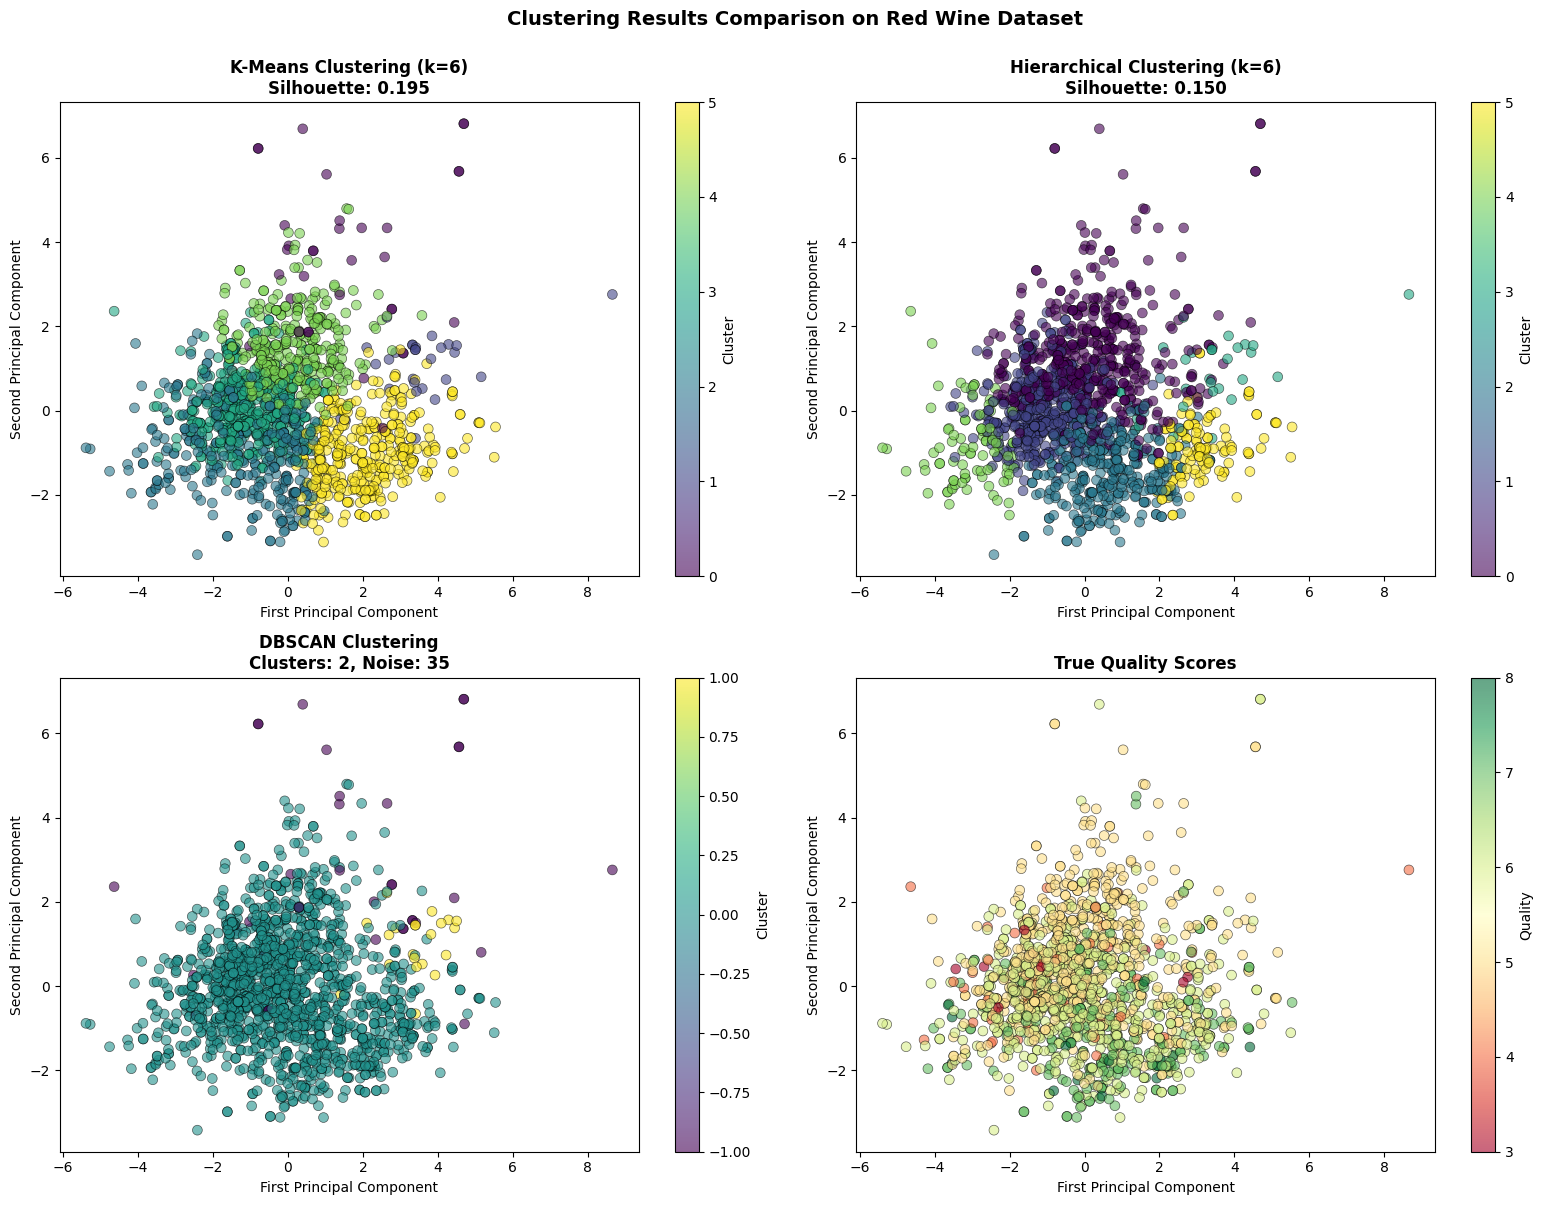

In [17]:
# Visualize all clustering methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-Means
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                               cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_title(f'K-Means Clustering (k={optimal_k})\nSilhouette: {silhouette_kmeans:.3f}',
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('First Principal Component')
axes[0, 0].set_ylabel('Second Principal Component')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# Hierarchical
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels,
                               cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_title(f'Hierarchical Clustering (k={optimal_k})\nSilhouette: {silhouette_hier:.3f}',
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('First Principal Component')
axes[0, 1].set_ylabel('Second Principal Component')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# DBSCAN
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels,
                               cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_title(f'DBSCAN Clustering\nClusters: {n_clusters}, Noise: {n_noise}',
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('First Principal Component')
axes[1, 0].set_ylabel('Second Principal Component')
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster')

# True quality labels
scatter4 = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true,
                               cmap='RdYlGn', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_title('True Quality Scores', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('First Principal Component')
axes[1, 1].set_ylabel('Second Principal Component')
plt.colorbar(scatter4, ax=axes[1, 1], label='Quality')

plt.suptitle('Clustering Results Comparison on Red Wine Dataset',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [18]:
# Compare clustering results with true quality
results_df = pd.DataFrame({
    'True_Quality': y_true,
    'KMeans_Cluster': kmeans_labels,
    'Hierarchical_Cluster': hierarchical_labels,
    'DBSCAN_Cluster': dbscan_labels
})

print("Cluster distribution by true quality (K-Means):")
print(pd.crosstab(results_df['True_Quality'], results_df['KMeans_Cluster']))

Cluster distribution by true quality (K-Means):
KMeans_Cluster   0   1    2    3    4    5
True_Quality                              
3                0   0    0    7    1    2
4                1   1    4   39    4    4
5               16  19   45  282  225   94
6               12   9  161  183   96  177
7                5   1   82   22   11   78
8                0   0   10    0    1    7


In [19]:
# Average quality per cluster for K-Means
cluster_quality = results_df.groupby('KMeans_Cluster')['True_Quality'].agg(['mean', 'count', 'std'])
cluster_quality.columns = ['Average_Quality', 'Count', 'Std_Dev']
cluster_quality = cluster_quality.sort_values('Average_Quality')

print("\nK-Means Cluster Characteristics:")
print(cluster_quality)


K-Means Cluster Characteristics:
                Average_Quality  Count   Std_Dev
KMeans_Cluster                                  
3                      5.326454    533  0.727025
1                      5.333333     30  0.606478
4                      5.340237    338  0.591414
0                      5.617647     34  0.779071
5                      5.955801    362  0.803891
2                      6.162252    302  0.762601


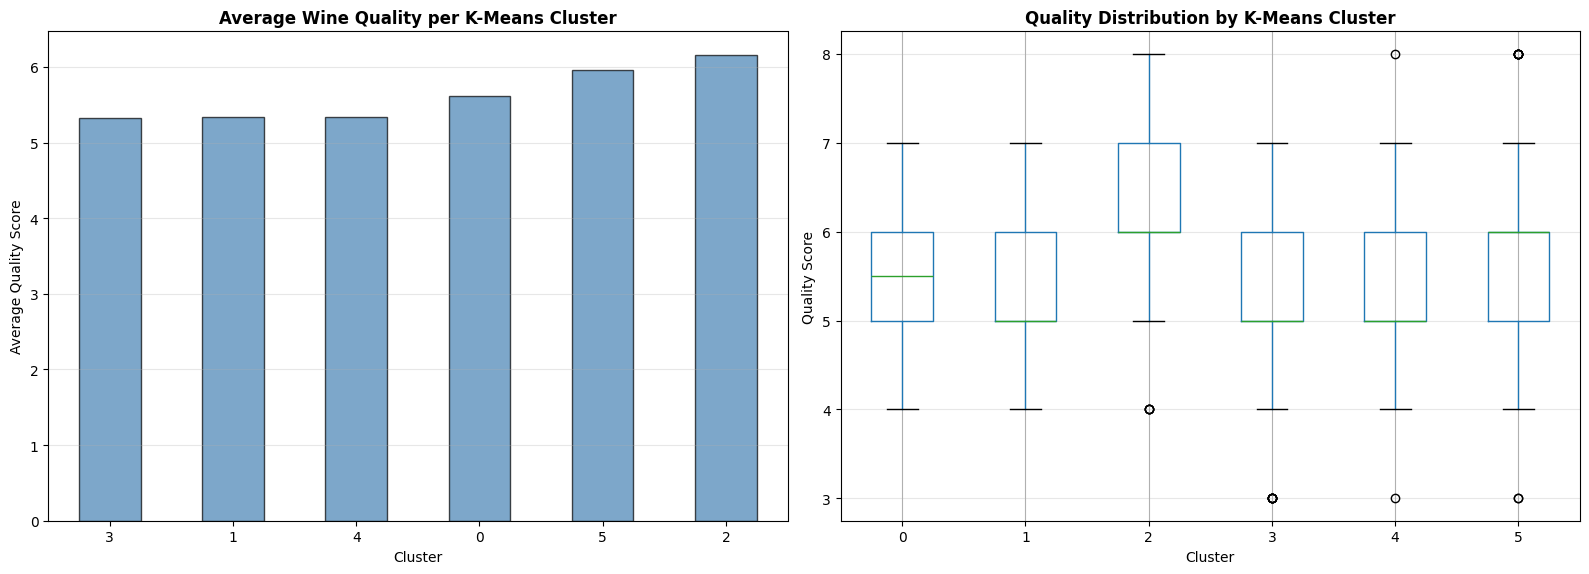

In [20]:
# Visualize cluster quality distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of average quality per cluster
cluster_quality['Average_Quality'].plot(kind='bar', ax=axes[0], color='steelblue',
                                         edgecolor='black', alpha=0.7)
axes[0].set_title('Average Wine Quality per K-Means Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Average Quality Score')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Box plot of quality distribution per cluster
results_df.boxplot(column='True_Quality', by='KMeans_Cluster', ax=axes[1])
axes[1].set_title('Quality Distribution by K-Means Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Quality Score')
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('')

plt.tight_layout()
plt.show()

In [21]:
# Summary of clustering evaluation metrics
summary = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [silhouette_kmeans, silhouette_hier, silhouette_dbscan if silhouette_dbscan != -1 else np.nan],
    'Davies-Bouldin Index': [db_kmeans, db_hier, db_dbscan if db_dbscan != -1 else np.nan],
    'Number of Clusters': [optimal_k, optimal_k, n_clusters]
})

print("\nClustering Algorithm Comparison:")
print(summary.to_string(index=False))

print("\nInterpretation:")
print("- Silhouette Score: Higher is better (range -1 to 1)")
print("- Davies-Bouldin Index: Lower is better")
print(f"\nBest algorithm based on Silhouette Score: {summary.loc[summary['Silhouette Score'].idxmax(), 'Algorithm']}")


Clustering Algorithm Comparison:
   Algorithm  Silhouette Score  Davies-Bouldin Index  Number of Clusters
     K-Means          0.194729              1.398426                   6
Hierarchical          0.149503              1.526313                   6
      DBSCAN          0.509911              0.674848                   2

Interpretation:
- Silhouette Score: Higher is better (range -1 to 1)
- Davies-Bouldin Index: Lower is better

Best algorithm based on Silhouette Score: DBSCAN


In [22]:
# Feature importance for clusters
# Calculate mean feature values for each cluster
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = kmeans_labels

cluster_means = df_with_clusters.groupby('Cluster').mean()
print("\nMean feature values per cluster:")
print(cluster_means)


Mean feature values per cluster:
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             8.170588          0.521618     0.351765        9.532353   
1             8.433333          0.529667     0.486000        1.963333   
2             7.113576          0.450066     0.241457        2.176821   
3             7.500938          0.651388     0.111220        2.268762   
4             8.190533          0.532589     0.286657        2.517899   
5            10.656354          0.406727     0.490773        2.648757   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
Cluster                                                                   
0         0.101412            34.176471            102.235294  0.999058   
1         0.347333            14.966667             62.933333  0.997087   
2         0.067854            17.079470             38.456954  0.994409   
3     

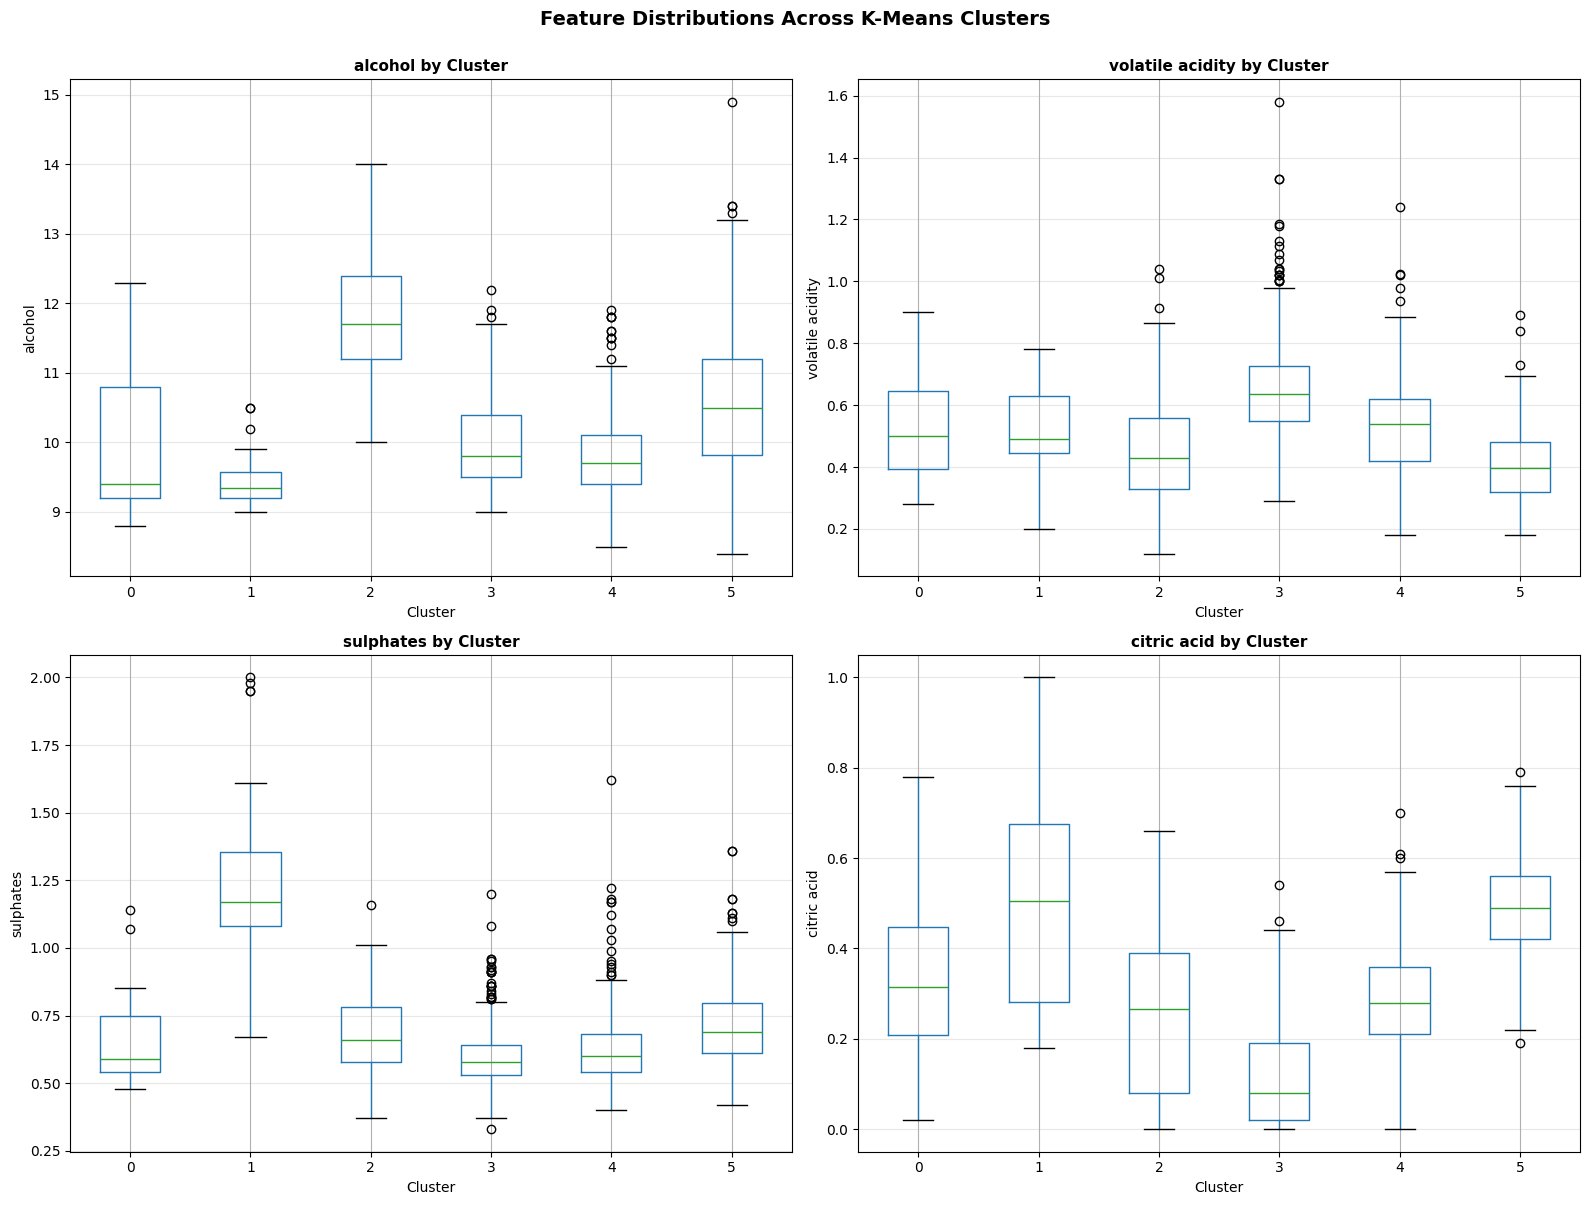

In [23]:
# Visualize feature distributions across clusters
features_to_plot = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    df_with_clusters.boxplot(column=feature, by='Cluster', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Cluster', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions Across K-Means Clusters', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [24]:
# Final summary
print("\n" + "="*80)
print("CLUSTERING ANALYSIS SUMMARY")
print("="*80)
print(f"\nDataset: Red Wine Quality ({df.shape[0]} samples, {df.shape[1]-1} features)")
print(f"Quality range: {df['quality'].min()} to {df['quality'].max()}")
print(f"\nClustering Configuration:")
print(f"- Number of clusters (k): {optimal_k}")
print(f"- Scaling method: StandardScaler")
print(f"\nBest Performing Algorithm: K-Means")
print(f"- Silhouette Score: {silhouette_kmeans:.3f}")
print(f"- Davies-Bouldin Index: {db_kmeans:.3f}")
print(f"\nKey Findings:")
print(f"- Clusters show varying quality levels")
print(f"- Quality scores range from {cluster_quality['Average_Quality'].min():.2f} to {cluster_quality['Average_Quality'].max():.2f} across clusters")
print(f"- PCA visualization shows moderate separation between clusters")
print("="*80)


CLUSTERING ANALYSIS SUMMARY

Dataset: Red Wine Quality (1599 samples, 11 features)
Quality range: 3 to 8

Clustering Configuration:
- Number of clusters (k): 6
- Scaling method: StandardScaler

Best Performing Algorithm: K-Means
- Silhouette Score: 0.195
- Davies-Bouldin Index: 1.398

Key Findings:
- Clusters show varying quality levels
- Quality scores range from 5.33 to 6.16 across clusters
- PCA visualization shows moderate separation between clusters
